First 30-ish trained models
---------------------------

In [1]:
# Import required libraries
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Grab all test data and leave out files
p = Path('../Models')

patternTest = re.compile(r'^Model_Run(?:[1-9]|10)_TestData\.csv$')
testFiles = sorted(str(f) for f in p.rglob('Model_Run*_TestData.csv') if patternTest.match(f.name))

patternLeaveOut = re.compile(r'^Model_Run(?:[1-9]|10)_LeaveOut_TestData\.csv$')
leaveOutFiles = sorted(str(f) for f in p.rglob('Model_Run*_LeaveOut_TestData.csv') if patternLeaveOut.match(f.name))

# Load in Test Data and Leave Out Test Data

In [5]:
datatest = pd.read_csv(r'../Data/DataTest.csv')

In [6]:
datatest

,Lat,Lon,Alt,Date,H2,O18,KPN_A,KPN_B,KPN_C,KPN_D,KPN_E
0,53.871300,8.705800,5.0,2001-02-15 00:00:00+01:00,-57.000000,-8.15000,0,0,1,0,0
1,48.184278,16.389575,196.0,2002-05-24 00:00:00+02:00,-44.800000,-6.36000,0,0,1,0,0
2,51.116535,17.029468,118.0,2005-03-23 00:00:00+01:00,-69.640949,-9.86775,0,0,0,1,0
3,-40.350000,-9.880000,54.0,1995-06-15 00:00:00+02:00,-16.400000,-4.17000,0,0,1,0,0
4,-65.079444,-63.977500,20.0,1987-01-15 00:00:00+01:00,-123.300000,-14.94000,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
18336,36.880000,30.700000,49.0,1964-12-15 00:00:00+01:00,-31.200000,-5.35000,0,0,1,0,0
18337,47.470511,21.490419,110.0,2004-08-13 00:00:00+02:00,-24.350000,-4.06000,0,0,0,1,0
18338,47.077778,15.448889,366.0,1990-10-15 00:00:00+02:00,-60.000000,-8.96000,0,0,0,1,0
18339,43.491116,-3.800556,52.0,2009-02-15 00:00:00+01:00,-35.670000,-6.38000,0,0,1,0,0


In [38]:
# Load the data frames into a single DataFrame with a column indicating model type and columns for each run
def load_data(files, path2ogData):
    # Load the base DataFrame from the original data and drop any predicted-value cols
    df = pd.read_csv(path2ogData)
    df = df.drop(columns=['O18 P', 'H2 P'], errors='ignore')

    # Load the original data for the Date column and ensure it's present/parsed
    ogData = pd.read_csv(path2ogData)
    df['Date'] = pd.to_datetime(ogData['Date'], utc=True)

    # Build idCols after ensuring 'Date' exists to avoid duplicates in the id_vars list
    idCols = df.columns.tolist()
    if 'Date' not in idCols:
        idCols.append('Date')

    # Iterate through files and load them into a list of DataFrames
    for file in files:
        # Determine model type and run number from filename
        modelType = file.split('\\')[2]
        modelRun = file.split('\\')[3].split('_')[1]

        # Load the dataframe
        tempDF = pd.read_csv(file)

        # Grab only the predicted columns
        tempDF = tempDF[['O18 P', 'H2 P']]

        # Add those columns to the main DataFrame with appropriate names
        df[f'O18 P-{modelType}-{modelRun}'] = tempDF['O18 P']
        df[f'H2 P-{modelType}-{modelRun}'] = tempDF['H2 P']
    
    # Melt the DataFrame to have a long format
    meltedDF =pd.melt(df, id_vars=idCols, var_name='Model', value_name='Predicted_Value')

    if 'Label' in meltedDF.columns:
        cols = ['Date', 'Lat', 'Lon', 'Alt','Label', 'O18', 'H2', 'Model', 'Predicted_Value']
    else:
        cols = ['Date', 'Lat', 'Lon', 'Alt', 'O18', 'H2', 'Model', 'Predicted_Value']
    meltedDF = meltedDF[cols]
    
    meltedDF[['Isotope', 'Model Type', 'Run']] = meltedDF['Model'].str.split('-', expand=True)

    # Pivot the DataFrame to have separate columns for O18 and H2 predicted values
    finalDF = meltedDF.pivot_table(index=['Date', 'Lat', 'Lon', 'Alt', 'O18', 'H2', 'Model Type', 'Run'] + (['Label'] if 'Label' in meltedDF.columns else []),
                                    columns='Isotope',
                                    values='Predicted_Value').reset_index()
    return finalDF
    

In [39]:
testData = load_data(testFiles, r'../Data/DataTest.csv')
testData

Isotope,Date,Lat,Lon,Alt,O18,H2,Model Type,Run,H2 P,O18 P
0,1960-06-14 22:00:00+00:00,51.930000,-10.250000,9.0,-5.90,-39.7,Global_B,Run1,-36.114346,-5.096331
1,1960-06-14 22:00:00+00:00,51.930000,-10.250000,9.0,-5.90,-39.7,Global_B,Run10,-37.339825,-5.798136
2,1960-06-14 22:00:00+00:00,51.930000,-10.250000,9.0,-5.90,-39.7,Global_B,Run2,-34.198067,-5.401716
3,1960-06-14 22:00:00+00:00,51.930000,-10.250000,9.0,-5.90,-39.7,Global_B,Run3,-34.612061,-5.479257
4,1960-06-14 22:00:00+00:00,51.930000,-10.250000,9.0,-5.90,-39.7,Global_B,Run4,-42.544041,-6.471288
...,...,...,...,...,...,...,...,...,...,...
531731,2024-07-14 22:00:00+00:00,45.438461,9.203081,126.0,-1.93,-12.6,PreWinds_B,Run5,-44.291374,-6.650131
531732,2024-07-14 22:00:00+00:00,45.438461,9.203081,126.0,-1.93,-12.6,PreWinds_B,Run6,-45.287800,-6.865627
531733,2024-07-14 22:00:00+00:00,45.438461,9.203081,126.0,-1.93,-12.6,PreWinds_B,Run7,-58.991501,-8.663555
531734,2024-07-14 22:00:00+00:00,45.438461,9.203081,126.0,-1.93,-12.6,PreWinds_B,Run8,-44.649078,-6.409257


In [40]:
leaveOut = load_data(leaveOutFiles, r'../Data/Leave_Out_Points/Leave_Out_Points_GNIP (2025-07-22).csv')
leaveOut

Isotope,Date,Lat,Lon,Alt,O18,H2,Model Type,Run,Label,H2 P,O18 P
0,1961-06-14 22:00:00+00:00,18.900000,72.820000,10,-1.50,-10.00,Global_B,Run1,hotWet,4.986673,-0.317893
1,1961-06-14 22:00:00+00:00,18.900000,72.820000,10,-1.50,-10.00,Global_B,Run10,hotWet,-4.156967,-0.949672
2,1961-06-14 22:00:00+00:00,18.900000,72.820000,10,-1.50,-10.00,Global_B,Run2,hotWet,-1.155946,-1.423423
3,1961-06-14 22:00:00+00:00,18.900000,72.820000,10,-1.50,-10.00,Global_B,Run3,hotWet,1.043220,-1.048969
4,1961-06-14 22:00:00+00:00,18.900000,72.820000,10,-1.50,-10.00,Global_B,Run4,hotWet,-0.375035,-1.602613
...,...,...,...,...,...,...,...,...,...,...,...
35027,2023-12-14 23:00:00+00:00,47.542609,7.583717,316,-11.58,-86.95,PreWinds_B,Run5,highData,-24.769846,-4.198294
35028,2023-12-14 23:00:00+00:00,47.542609,7.583717,316,-11.58,-86.95,PreWinds_B,Run6,highData,-27.855759,-4.969678
35029,2023-12-14 23:00:00+00:00,47.542609,7.583717,316,-11.58,-86.95,PreWinds_B,Run7,highData,-22.425007,-4.553798
35030,2023-12-14 23:00:00+00:00,47.542609,7.583717,316,-11.58,-86.95,PreWinds_B,Run8,highData,-26.776527,-4.896466


# How did it perform?

In [68]:
# First to define metric to evaluate model performance
def kge(observed, predicted):
    mean_observed = np.mean(observed)
    mean_predicted = np.mean(predicted)
    std_observed = np.std(observed)
    std_predicted = np.std(predicted)
    r = np.corrcoef(observed, predicted)[0, 1]
    kge_value = 1 - np.sqrt((r - 1) ** 2 + (std_predicted / std_observed - 1) ** 2 + (mean_predicted / mean_observed - 1) ** 2)
    return kge_value

In [69]:
# Create a table to display KGE values and RMSE for each model type on test data and leave out data
model_types = testData['Model Type'].unique()
results = []
for model_type in model_types:
    for dataset, data_label in [(testData, 'Test Data'), (leaveOut, 'Leave Out Data')]:
        subset = data_label
        observed_O18 = dataset[dataset['Model Type'] == model_type]['O18']
        predicted_O18 = dataset[dataset['Model Type'] == model_type]['O18 P']
        observed_H2 = dataset[dataset['Model Type'] == model_type]['H2']
        predicted_H2 = dataset[dataset['Model Type'] == model_type]['H2 P']
        
        kge_O18 = kge(observed_O18, predicted_O18)
        kge_H2 = kge(observed_H2, predicted_H2)
        
        rmse_O18 = np.sqrt(np.mean((observed_O18 - predicted_O18) ** 2))
        rmse_H2 = np.sqrt(np.mean((observed_H2 - predicted_H2) ** 2))
        
        results.append({
            'Model Type': model_type,
            'Dataset': subset,
            'KGE O18': kge_O18,
            'KGE H2': kge_H2,
            'RMSE O18': rmse_O18,
            'RMSE H2': rmse_H2
        })

In [71]:
results_df = pd.DataFrame(results)
results_df

,Model Type,Dataset,KGE O18,KGE H2,RMSE O18,RMSE H2
0,Global_B,Test Data,0.726611,0.756915,3.187014,24.293105
1,Global_B,Leave Out Data,0.749631,0.765856,4.381128,33.852372
2,HighLowLat_B,Test Data,-0.014048,-0.009185,6.901771,56.218117
3,HighLowLat_B,Leave Out Data,-0.189390,-0.200393,11.295945,91.884439
4,PreWinds_B,Test Data,-0.017796,-0.013469,6.920215,56.405905
5,PreWinds_B,Leave Out Data,-0.022530,-0.029609,10.202256,83.082694


# Plot the Leave Out Test Data

## O18

<Axes: xlabel='O18', ylabel='O18 P'>

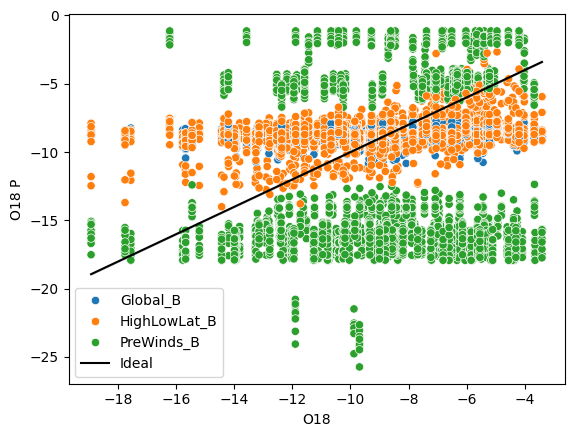

In [ ]:
testLabel = 'highData'

# Plot the Leave Out Test Data predictions vs ideal
sns.scatterplot(data=leaveOut[leaveOut['Label'] == testLabel], x='O18', y='O18 P', hue='Model Type')
sns.lineplot(data=leaveOut[leaveOut['Label'] == testLabel], x='O18', y='O18', color='black', label='Ideal')

<Axes: xlabel='Date', ylabel='O18'>

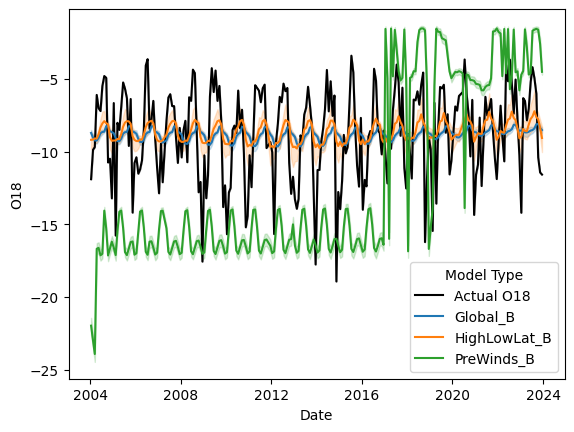

In [56]:
# Plot the Leave Out Test Data
sns.lineplot(data=leaveOut[leaveOut['Label'] == testLabel], x='Date', y='O18', label='Actual O18', color='black')
sns.lineplot(data=leaveOut[leaveOut['Label'] == testLabel], x='Date', y='O18 P', hue='Model Type', dashes=True)

<Axes: xlabel='Date', ylabel='O18'>

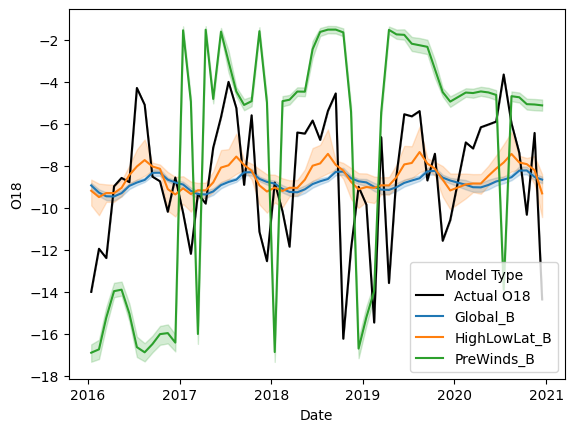

In [65]:
# Plot the Leave Out Test Data for specific year
startYear = 2016
endYear = 2020
sns.lineplot(data=leaveOut[(leaveOut['Label'] == testLabel) & (leaveOut['Date'].dt.year >= startYear) & (leaveOut['Date'].dt.year <= endYear)], x='Date', y='O18', label='Actual O18', color='black')
sns.lineplot(data=leaveOut[(leaveOut['Label'] == testLabel) & (leaveOut['Date'].dt.year >= startYear) & (leaveOut['Date'].dt.year <= endYear)], x='Date', y='O18 P', hue='Model Type', dashes=True)

## H2

<Axes: xlabel='H2', ylabel='H2 P'>

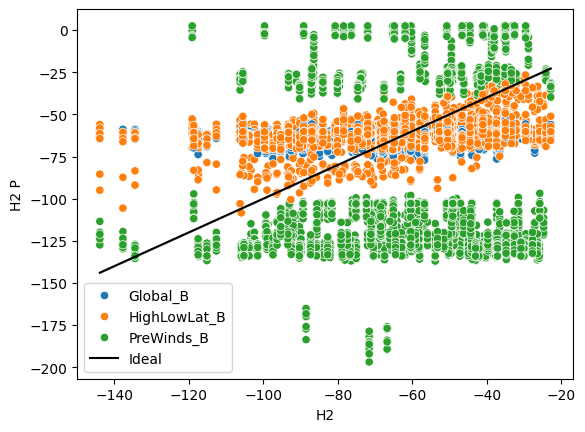

In [57]:
# Plot the Leave Out Test Data predictions vs ideal
sns.scatterplot(data=leaveOut[leaveOut['Label'] == testLabel], x='H2', y='H2 P', hue='Model Type')
sns.lineplot(data=leaveOut[leaveOut['Label'] == testLabel], x='H2', y='H2', color='black', label='Ideal')

<Axes: xlabel='Date', ylabel='H2'>

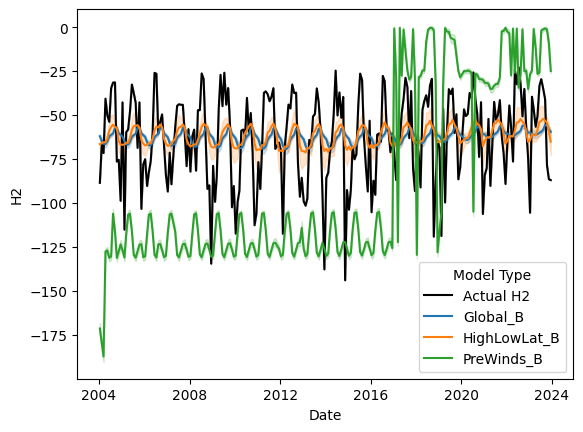

In [62]:
# Plot the Leave Out Test Data
sns.lineplot(data=leaveOut[(leaveOut['Label'] == testLabel)], x='Date', y='H2', label='Actual H2', color='black')
sns.lineplot(data=leaveOut[(leaveOut['Label'] == testLabel)], x='Date', y='H2 P', hue='Model Type', dashes=True)

<Axes: xlabel='Date', ylabel='H2'>

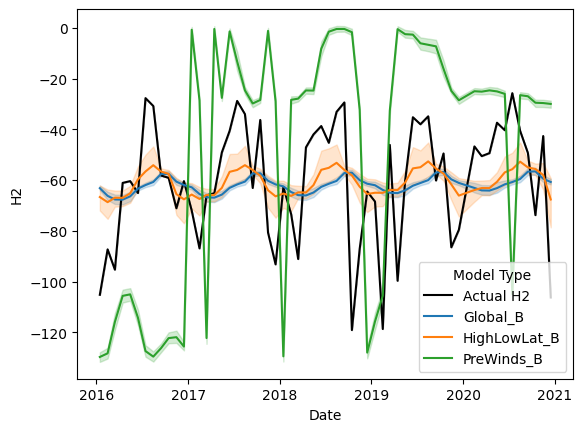

In [66]:
# Plot the Leave Out Test Data for specific year
startYear = 2016
endYear = 2020
sns.lineplot(data=leaveOut[(leaveOut['Label'] == testLabel) & (leaveOut['Date'].dt.year >= startYear) & (leaveOut['Date'].dt.year <= endYear)], x='Date', y='H2', label='Actual H2', color='black')
sns.lineplot(data=leaveOut[(leaveOut['Label'] == testLabel) & (leaveOut['Date'].dt.year >= startYear) & (leaveOut['Date'].dt.year <= endYear)], x='Date', y='H2 P', hue='Model Type', dashes=True)

# Plot for the Test Data


<Axes: xlabel='O18', ylabel='O18 P'>

C:\Users\jaxgr\AppData\Roaming\Python\Python313\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\jaxgr\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


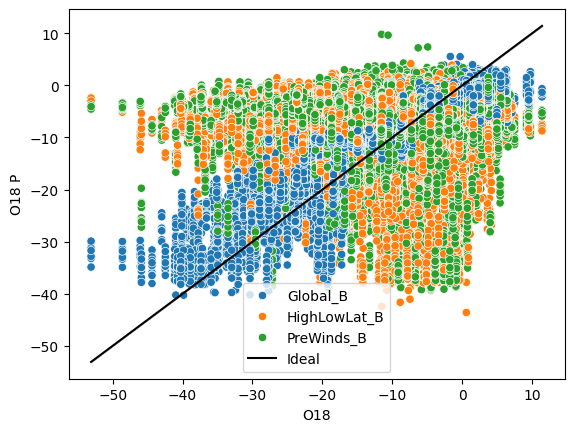

In [73]:
# Plot predicted vs actual for test data
sns.scatterplot(data=testData, x='O18', y='O18 P', hue='Model Type')
sns.lineplot(data=testData, x='O18', y='O18', color='black', label='Ideal')